<a href="https://colab.research.google.com/github/krishna-murari23/UGRP2026/blob/main/PINNProblems_2DConduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case 1: 1D Steady-State Conduction - Lumped Capacity Model

# Case 2: 2D Steady-State Heat Conduction with Uniform Generation(Dirichlet BC)

**Problem.** Square plate, $1\text{ m}\times1\text{ m}$, thermal conductivity $k=238\ \text{W/m·K}$, uniform volumetric heat generation $\dot q = 10^6\ \text{W/m}^3$.

Governing equation:
$$\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}+\frac{\dot q}{k}=0,\qquad (x,y)\in(0,1)^2$$

Dirichlet boundary conditions:
$$T(0,y)=700\text{ K},\qquad T(1,y)=T(x,0)=T(x,1)=350\text{ K}$$



In [ ]:
k = 238.0        # W/m.K
q = 1e6          # W/m^3
L = 1.0          # m
T_left = 700.0   # K
T_other = 350.0  # K (top, bottom, right)

## 1. Analytical solution

### 1.1 Superposition

Write $T = T_p(x) + T_h(x,y)$, where $T_p$ is a particular solution carrying the generation term and depending on $x$ only, and $T_h$ solves the homogeneous (Laplace) equation with whatever boundary residual is left over.

$T_p$ must satisfy $T_p''=-\dot q/k$. Pick it to match the left/right boundary values exactly, so the residual problem has **zero** boundary condition on those two edges:
$$T_p(x) = -\frac{\dot q}{2k}x^2 + Bx + T_{\text{left}},\qquad B = -( T_{\text{left}}-T_{\text{other}}) + \frac{\dot q}{2k}$$

which gives $T_p(0)=700$ and $T_p(1)=300$ automatically.

Then $T_h=T-T_p$ satisfies $\nabla^2 T_h=0$ with
$$T_h(0,y)=T_h(1,y)=0,\qquad T_h(x,0)=T_h(x,1)=g(x):=T_{\text{other}}-T_p(x)$$

Top and bottom carry the *same* nonzero profile $g(x)$ — a direct consequence of three of the four sides sharing the same 300 K value.

### 1.2 Homogeneous problem by separation of variables

Zero BC on $x=0,1$ $\Rightarrow$ expand in $\sin(n\pi x)$. Laplace's equation forces $Y_n''-(n\pi)^2Y_n=0$, and since the $y=0$ and $y=1$ conditions are identical, the solution is symmetric about $y=\tfrac12$:
$$T_h(x,y)=\sum_{n=1}^{\infty} g_n\,\frac{\cosh\!\big(n\pi(y-\tfrac12)\big)}{\cosh(n\pi/2)}\sin(n\pi x),\qquad g_n = 2\int_0^1 g(x)\sin(n\pi x)\,dx$$

Writing $g(x)=ax^2+bx+c$ with $a=\dot q/2k$, $b=-B$, $c=T_{\text{other}}-T_{\text{left}}$, the integral has a closed form. Using $a+b=T_{\text{left}}-T_{\text{other}}$ (independent of $\dot q,k$) simplifies it to

$$g_n=\begin{cases}\dfrac{-2(T_{\text{left}}-T_{\text{other}})}{n\pi}, & n\text{ even}\\[2mm]
\dfrac{-2(T_{\text{left}}-T_{\text{other}})}{n\pi}-\dfrac{8a}{n^3\pi^3}, & n\text{ odd}\end{cases}$$


Full solution: $T(x,y)=T_p(x)+T_h(x,y)$. The series is truncated at $N$ terms for evaluation.

In [ ]:
import numpy as np

a = q/(2*k)
B = -(T_left - T_other) + a

def T_particular(x):
    return -a*x**2 + B*x + T_left

def g(x):
    return T_other - T_particular(x)

def g_n(n):
    base = -2*(T_left - T_other)/(n*np.pi)
    if n % 2 == 0:
        return base
    return base - 8*a/(n**3*np.pi**3)

def T_analytical(x, y, N=200):
    T = T_particular(x)
    for n in range(1, N+1):
        T += g_n(n) * np.cosh(n*np.pi*(y-0.5))/np.cosh(n*np.pi/2) * np.sin(n*np.pi*x)
    return T

In [ ]:
from scipy.integrate import quad

# g_n formula vs. direct numerical integration
for n in range(1, 6):
    num, _ = quad(lambda x: 2*g(x)*np.sin(n*np.pi*x), 0, 1)
    print(f"n={n}  formula={g_n(n): .6f}  numeric={num: .6f}")

n=1  formula=-764.859516  numeric=-764.859516
n=2  formula=-111.408460  numeric=-111.408460
n=3  formula=-94.347958  numeric=-94.347958
n=4  formula=-55.704230  numeric=-55.704230
n=5  formula=-48.899725  numeric=-48.899725


In [ ]:
# boundary check
ys = np.linspace(0, 1, 5)
print("T(0,y):", [round(T_analytical(0.0, y), 3) for y in ys])
print("T(1,y):", [round(T_analytical(1.0, y), 3) for y in ys])
xs = np.linspace(0, 1, 6)
print("T(x,0):", [round(T_analytical(x, 0.0), 3) for x in xs])
print("T(x,1):", [round(T_analytical(x, 1.0), 3) for x in xs])

T(0,y): [np.float64(700.0), np.float64(700.0), np.float64(700.0), np.float64(700.0), np.float64(700.0)]
T(1,y): [np.float64(350.0), np.float64(350.0), np.float64(350.0), np.float64(350.0), np.float64(350.0)]
T(x,0): [np.float64(700.0), np.float64(351.714), np.float64(350.767), np.float64(350.405), np.float64(350.181), np.float64(350.0)]
T(x,1): [np.float64(700.0), np.float64(351.714), np.float64(350.767), np.float64(350.405), np.float64(350.181), np.float64(350.0)]


Boundaries match exactly, except right at the two corners $(0,0)$ and $(0,1)$, where the prescribed temperature jumps discontinuously from 700 K to 350K. Gibb's phenomenon arises at these points; due to the jump discontinuity , these points are also the dominant error term for the PINN

min=350.00 K   max=780.53 K   mean=582.29 K
center T(0.5,0.5) = 747.04 K


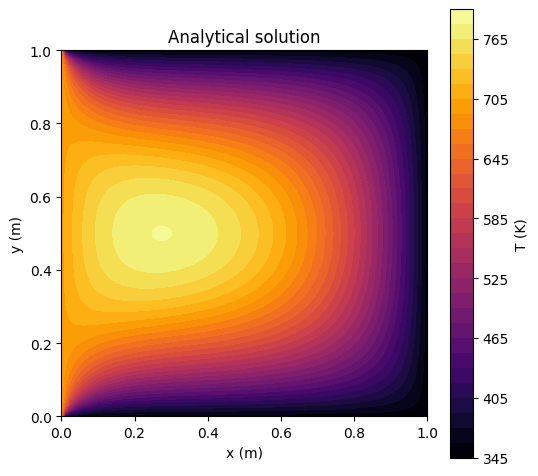

In [ ]:
import matplotlib.pyplot as plt

n_grid = 101
xg = np.linspace(0, 1, n_grid)
yg = np.linspace(0, 1, n_grid)
Xg, Yg = np.meshgrid(xg, yg)
Tg = np.array([[T_analytical(x, y, N=200) for x in xg] for y in yg])

print(f"min={Tg.min():.2f} K   max={Tg.max():.2f} K   mean={Tg.mean():.2f} K")
print(f"center T(0.5,0.5) = {T_analytical(0.5,0.5):.2f} K")

fig, ax = plt.subplots(figsize=(5.5,5))
c = ax.contourf(Xg, Yg, Tg, levels=40, cmap='inferno')
plt.colorbar(c, label='T (K)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_title('Analytical solution')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 2. PINN

### 2.1 Nondimensionalization

We get the scale from the governing equation itself. Substituting $\theta=(T-T_{\text{ref}})/\Delta T$ into the PDE,
$$\theta_{xx}+\theta_{yy}+\frac{\dot q L^2}{k\,\Delta T}=0$$
Choosing $\Delta T=\dot q L^2/k$ makes the source coefficient exactly 1:
$$\theta_{xx}+\theta_{yy}+1=0,\qquad \theta=\frac{T-T_{\text{ref}}}{\Delta T},\ T_{\text{ref}}=300\text{ K}$$
$\theta_{\text{left}} = (700-300)/\Delta T$, all other boundaries $\theta=0$.

### 2.2 Network

Single hidden layer now with a 2-component input:
$$s_j = W^1_{j,1}x+W^1_{j,2}y+b^1_j,\quad h_j=\tanh(s_j),\quad \hat\theta = \sum_j w^2_j h_j + b^2$$

Reusing the same forward-pass activations $h_j$ (as in the 1D derivation):
$$\frac{\partial \hat\theta}{\partial x}=\sum_j w^2_j(1-h_j^2)W^1_{j,1},\qquad \frac{\partial^2\hat\theta}{\partial x^2}=-2\sum_j w^2_j\,h_j(1-h_j^2)\,(W^1_{j,1})^2$$
and symmetrically in $y$. So the residual is
$$f=\hat\theta_{xx}+\hat\theta_{yy}+1=-2\sum_j w^2_j\,\phi_j\,c_j+1,\qquad \phi_j=h_j(1-h_j^2),\ \ c_j=(W^1_{j,1})^2+(W^1_{j,2})^2$$

No cross-derivative term is needed — the Laplacian only touches pure second derivatives, so this stays a direct 2D generalization of the 1D residual rather than something structurally new.

### 2.3 Loss gradients (double backprop, by hand)

Boundary loss $\text{MSE}_\theta=\frac1{N_b}\sum e_i^2$, $e_i=\hat\theta_i-\theta_i^{\text{target}}$, is standard MLP backprop.

For the PDE loss $\text{MSE}_f=\frac1{N_f}\sum f_i^2$, differentiate $f$ itself w.r.t. the parameters. With $\phi_j=h_j-h_j^3$ (so $d\phi_j/dh_j=1-3h_j^2$):

$$\frac{\partial f}{\partial w^2_j}=-2\phi_jc_j,\qquad \frac{\partial f}{\partial b^2}=0$$

$$\frac{\partial f}{\partial W^1_{j,1}}=-2w^2_j\Big[(1-3h_j^2)(1-h_j^2)\,x\cdot c_j+\phi_j\cdot 2W^1_{j,1}\Big]\quad\text{(symmetric in }y\text{ for }W^1_{j,2}\text{)}$$

$$\frac{\partial f}{\partial b^1_j}=-2w^2_j(1-3h_j^2)(1-h_j^2)\,c_j$$

$b^2$ drops out of $f$ entirely — a constant output offset has zero second derivative, so the bias never receives a gradient contribution from the PDE term, only from the boundary term.

In [ ]:
m = 24  # hidden layer
rng = np.random.default_rng(0)
W1 = rng.standard_normal((m, 2)) * 0.7
b1 = np.zeros(m)
w2 = rng.standard_normal(m) * 0.5
b2 = 0.0

dT = q * L**2 / k
T_ref = 300.0 # value of the jump
theta_left = (T_left - T_ref) / dT
theta_other = (T_other - T_ref) / dT   #will be 0

In [ ]:
def forward(X):
    H = np.tanh(X @ W1.T + b1)
    return H @ w2 + b2, H

def residual(X):
    H = np.tanh(X @ W1.T + b1)
    c = W1[:,0]**2 + W1[:,1]**2
    phi = H * (1 - H**2)
    f = -2*(phi*c) @ w2 + 1.0
    return f, H, phi, c

In [ ]:
# boundary + collocation points
n_side = 25
xs = np.linspace(0, 1, n_side)
Xb = np.vstack([
    np.stack([np.zeros(n_side), xs], 1),   # left
    np.stack([np.ones(n_side),  xs], 1),   # right
    np.stack([xs, np.zeros(n_side)], 1),   # bottom
    np.stack([xs, np.ones(n_side)], 1),    # top
])
theta_b = np.concatenate([np.full(n_side, theta_left), np.full(3*n_side, theta_other)])

n_f = 30
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, n_f), np.linspace(0.02, 0.98, n_f))
Xf = np.stack([gx.ravel(), gy.ravel()], 1)

In [ ]:
def grads():
    N_b, N_f = Xb.shape[0], Xf.shape[0]

    theta_pred, H_b = forward(Xb)
    e = theta_pred - theta_b
    dphi_b = 1 - H_b**2
    prod_b = e[:,None] * w2[None,:] * dphi_b
    gW1_bc = (2/N_b) * (prod_b.T @ Xb)
    gb1_bc = (2/N_b) * prod_b.sum(0)
    gW2_bc = (2/N_b) * (H_b.T @ e)
    gb2_bc = (2/N_b) * e.sum()

    f, H_f, phi_f, c = residual(Xf)
    h2 = H_f**2
    dphidh = 1 - 3*h2
    onemh2 = 1 - h2
    x_, y_ = Xf[:,0:1], Xf[:,1:2]

    dfdW11 = -2*w2[None,:]*(dphidh*onemh2*x_*c[None,:] + phi_f*2*W1[:,0][None,:])
    dfdW12 = -2*w2[None,:]*(dphidh*onemh2*y_*c[None,:] + phi_f*2*W1[:,1][None,:])
    dfdb1  = -2*w2[None,:]*(dphidh*onemh2*c[None,:])

    gW1_pde = np.stack([(2/N_f)*(f[:,None]*dfdW11).sum(0),
                         (2/N_f)*(f[:,None]*dfdW12).sum(0)], axis=1)
    gb1_pde = (2/N_f) * (f[:,None]*dfdb1).sum(0)
    gW2_pde = (2/N_f) * (f[:,None]*(-2*phi_f*c[None,:])).sum(0)
    # gb2_pde = 0

    return (gW1_bc+gW1_pde, gb1_bc+gb1_pde, gW2_bc+gW2_pde, gb2_bc,
            np.mean(e**2), np.mean(f**2))

### 2.4 Losses and approximation to the analytical solution


In [ ]:
import torch

rng2 = np.random.default_rng(1)
m_t, Xb_t, Tb_t, Xf_t = 6, rng2.random((7,2)), rng2.standard_normal(7), rng2.random((9,2))
W1n = rng2.standard_normal((m_t,2))*0.6; b1n = rng2.standard_normal(m_t)*0.3
w2n = rng2.standard_normal(m_t)*0.4; b2n = rng2.standard_normal()

def grads_test(W1,b1,w2,b2,Xb,Tb,Xf):
    N_b, N_f = Xb.shape[0], Xf.shape[0]
    H_b = np.tanh(Xb@W1.T+b1); e = H_b@w2+b2 - Tb
    common_b = e[:,None]*w2[None,:]*(1-H_b**2)
    gW1 = (2/N_b)*(common_b.T@Xb); gb1 = (2/N_b)*common_b.sum(0)
    gW2 = (2/N_b)*(H_b.T@e); gb2 = (2/N_b)*e.sum()
    H_f = np.tanh(Xf@W1.T+b1); c = W1[:,0]**2+W1[:,1]**2; phi_f = H_f*(1-H_f**2)
    f = -2*(phi_f*c)@w2 + 1.0
    dphidh = 1-3*H_f**2; onemh2 = 1-H_f**2; x_,y_ = Xf[:,0:1],Xf[:,1:2]
    dfdW11=-2*w2[None,:]*(dphidh*onemh2*x_*c[None,:]+phi_f*2*W1[:,0][None,:])
    dfdW12=-2*w2[None,:]*(dphidh*onemh2*y_*c[None,:]+phi_f*2*W1[:,1][None,:])
    dfdb1 =-2*w2[None,:]*(dphidh*onemh2*c[None,:])
    gW1 += np.stack([(2/N_f)*(f[:,None]*dfdW11).sum(0), (2/N_f)*(f[:,None]*dfdW12).sum(0)],1)
    gb1 += (2/N_f)*(f[:,None]*dfdb1).sum(0)
    gW2 += (2/N_f)*(f[:,None]*(-2*phi_f*c[None,:])).sum(0)
    return gW1, gb1, gW2, gb2

gW1h, gb1h, gW2h, gb2h = grads_test(W1n,b1n,w2n,b2n,Xb_t,Tb_t,Xf_t)

W1t = torch.tensor(W1n, requires_grad=True); b1t = torch.tensor(b1n, requires_grad=True)
w2t = torch.tensor(w2n, requires_grad=True); b2t = torch.tensor(b2n, requires_grad=True)
Xbt, Tbt, Xft = torch.tensor(Xb_t), torch.tensor(Tb_t), torch.tensor(Xf_t, requires_grad=True)

thb = torch.tanh(Xbt@W1t.T+b1t)@w2t + b2t
loss_bc = ((thb-Tbt)**2).mean()
thf = torch.tanh(Xft@W1t.T+b1t)@w2t + b2t
g1 = torch.autograd.grad(thf.sum(), Xft, create_graph=True)[0]
gxx = torch.autograd.grad(g1[:,0].sum(), Xft, create_graph=True)[0][:,0]
gyy = torch.autograd.grad(g1[:,1].sum(), Xft, create_graph=True)[0][:,1]
loss_pde = ((gxx+gyy+1.0)**2).mean()
(loss_bc+loss_pde).backward()

print("max |dW1| diff:", np.max(np.abs(gW1h - W1t.grad.numpy())))
print("max |db1| diff:", np.max(np.abs(gb1h - b1t.grad.numpy())))
print("max |dw2| diff:", np.max(np.abs(gW2h - w2t.grad.numpy())))
print("|db2| diff:    ", np.abs(gb2h - b2t.grad.item()))

max |dW1| diff: 1.0596698074571975e-08
max |db1| diff: 1.8477480212553132e-08
max |dw2| diff: 2.631450746193309e-08
|db2| diff:     6.090012649728749e-08


Agrees with autograd to ~$10^{-9}$ (float64 roundoff) — the hand-derived residual and its gradient are correct. On to training the actual network.

In [ ]:
lr = 0.02
n_iters = 150_000
history = []

for it in range(n_iters + 1):
    gW1, gb1, gW2, gb2_, l_bc, l_pde = grads()
    W1 -= lr*gW1; b1 -= lr*gb1; w2 -= lr*gW2; b2 -= lr*gb2_
    if it % 15_000 == 0:
        history.append((it, l_bc, l_pde))
        print(f"{it:7d}  bc={l_bc:.6f}  pde={l_pde:.6f}  total={l_bc+l_pde:.6f}")

      0  bc=0.042775  pde=0.313665  total=0.356440
  15000  bc=0.000813  pde=0.000361  total=0.001174
  30000  bc=0.000657  pde=0.000185  total=0.000842
  45000  bc=0.000635  pde=0.000161  total=0.000797
  60000  bc=0.000627  pde=0.000144  total=0.000772
  75000  bc=0.000622  pde=0.000132  total=0.000754
  90000  bc=0.000617  pde=0.000123  total=0.000740
 105000  bc=0.000613  pde=0.000116  total=0.000729
 120000  bc=0.000610  pde=0.000110  total=0.000720
 135000  bc=0.000607  pde=0.000105  total=0.000712
 150000  bc=0.000604  pde=0.000101  total=0.000705


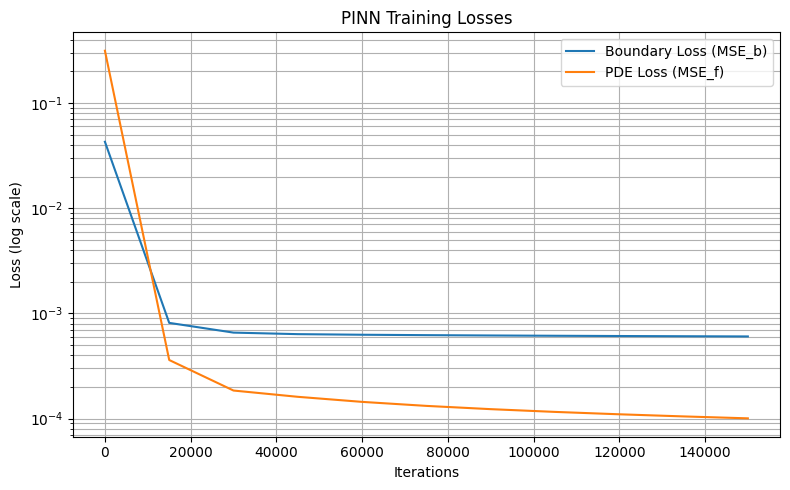

In [ ]:
history_arr = np.array(history)
iterations = history_arr[:, 0]
bc_loss = history_arr[:, 1]
pde_loss = history_arr[:, 2]

plt.figure(figsize=(8, 5))
plt.plot(iterations, bc_loss, label='Boundary Loss (MSE_b)')
plt.plot(iterations, pde_loss, label='PDE Loss (MSE_f)')
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Loss (log scale)')
plt.title('PINN Training Losses')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [ ]:
theta_grid, _ = forward(np.stack([Xg.ravel(), Yg.ravel()], 1))
T_pinn = (T_ref + dT*theta_grid).reshape(Xg.shape)
err = T_pinn - Tg

print(f"max |error| = {np.max(np.abs(err)):.1f} K")
print(f"mean |error| = {np.mean(np.abs(err)):.1f} K")
print(f"relative L2 error = {np.linalg.norm(err)/np.linalg.norm(Tg):.4f}")
print(f"center: PINN={T_ref+dT*forward(np.array([[0.5,0.5]]))[0][0]:.1f} K   exact={T_analytical(0.5,0.5):.1f} K")

max |error| = 322.7 K
mean |error| = 47.1 K
relative L2 error = 0.0895
center: PINN=792.8 K   exact=747.0 K


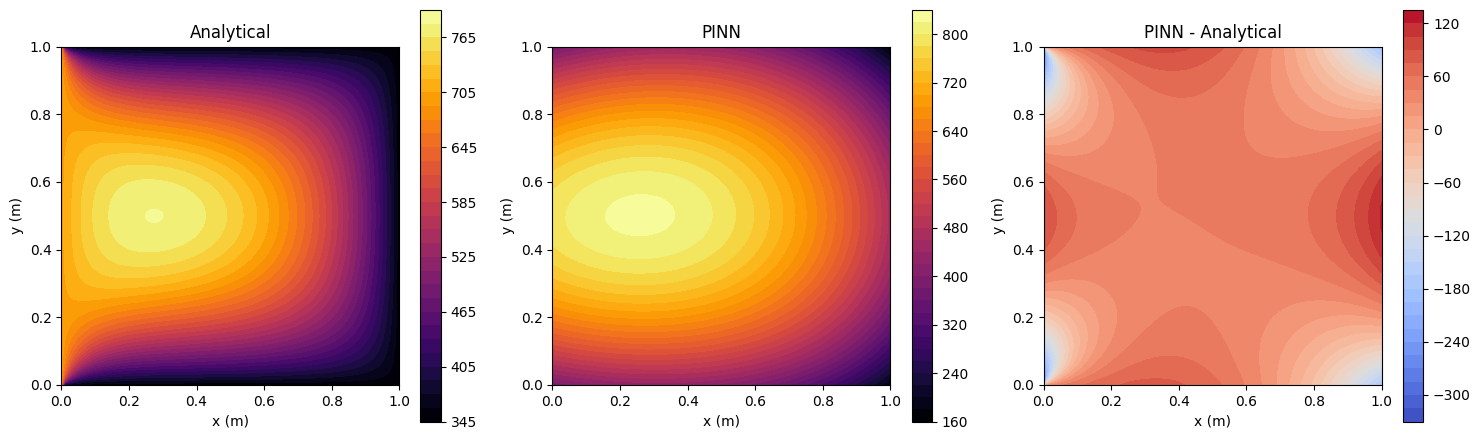

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, field, title, cmap in zip(
        axes, [Tg, T_pinn, err],
        ['Analytical', 'PINN', 'PINN - Analytical'],
        ['inferno', 'inferno', 'coolwarm']):
    c = ax.contourf(Xg, Yg, field, levels=40, cmap=cmap)
    plt.colorbar(c, ax=ax)
    ax.set_title(title); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 3. Notes

The error is not uniform: it's concentrated at the two corners $(0,0)$ and $(0,1)$, where the boundary data itself is discontinuous (700 K meets 350 K).

This single-hidden-layer network trained with **plain full-batch gradient descent** converges slowly, the loss is still decreasing gradually at 150k iterations rather than plateauing cleanly.


# Case 3: 2D Steady-State Heat Conduction without generation(Neumann + Dirichlet BC)

**Problem.** Square plate, $1\text{ m}\times1\text{ m}$, $k=10\ \text{W/m·K}$, **no volumetric generation**.

Governing equation (Laplace):
$$\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}=0,\qquad (x,y)\in(0,1)^2$$

Boundary conditions(Neumann + Dirichlet) :
$$-k\left.\frac{\partial T}{\partial n}\right|_{x=0} = q_0 = 1000\ \text{W/m}^2\ \text{(applied into the plate)}, \qquad T(1,y)=T(x,0)=T(x,1)=100\text{ K}$$


In [3]:
k = 10.0
q0 = 1000.0      # W/m^2, applied into the domain at x=0
T_other = 100.0  # K
L = 1.0

## 1. Analytical solution


### 1.1 Superposition

All three Dirichlet sides share the *same* value, so shift by a constant: $T=T_{\text{other}}+\varphi(x,y)$, with $\varphi$ harmonic ($\nabla^2\varphi=0$, unaffected by a constant shift) and
$$\varphi(1,y)=\varphi(x,0)=\varphi(x,1)=0,\qquad \frac{\partial\varphi}{\partial x}(0,y)=-Q$$


### 1.2 Separation of variables

Zero Dirichlet BC at $y=0,1$ $\Rightarrow$ expand in $\sin(n\pi y)$. Laplace forces $X_n''-(n\pi)^2X_n=0$. Pick the hyperbolic basis that **automatically satisfies $\varphi(1,y)=0$**:
$$\varphi(x,y)=\sum_{n=1}^\infty A_n\sinh\big(n\pi(1-x)\big)\sin(n\pi y)$$

Apply the Neumann condition at $x=0$: $\dfrac{\partial\varphi}{\partial x}(0,y)=-\sum_n A_n\,n\pi\cosh(n\pi)\sin(n\pi y)$ must equal $-Q$ (a constant) for all $y\in(0,1)$ — so match Fourier sine coefficients of the constant $-Q$:
$$-Q = \sum_n b_n\sin(n\pi y),\qquad b_n = 2\int_0^1(-Q)\sin(n\pi y)\,dy = \frac{-2Q\,(1-(-1)^n)}{n\pi}$$

giving $b_n=0$ for even $n$ and $b_n=-4Q/(n\pi)$ for odd $n$. Setting $-A_n n\pi\cosh(n\pi)=b_n$:

$$A_n = \frac{4Q}{n^2\pi^2\cosh(n\pi)}\quad (n\text{ odd}),\qquad A_n=0\quad(n\text{ even})$$

$$\boxed{T(x,y) = T_{\text{other}} + \sum_{n\text{ odd}} \frac{4Q}{n^2\pi^2\cosh(n\pi)}\,\sinh\big(n\pi(1-x)\big)\sin(n\pi y)}$$


In [4]:
import numpy as np

Q = q0/k   # 100 K/m

def T_analytical(x, y, N=300):
    T = T_other
    for n in range(1, N+1, 2):        # odd n only
        a, b = n*np.pi*(1-x), n*np.pi
        ratio = np.exp(a-b) * (1-np.exp(-2*a)) / (1+np.exp(-2*b))
        A_n = 4*Q/(n**2*np.pi**2)
        T += A_n * ratio * np.sin(n*np.pi*y)
    return T

In [5]:
xs = np.linspace(0, 1, 6)
print("T(x,0):", [round(T_analytical(x,0.0),3) for x in xs])
print("T(x,1):", [round(T_analytical(x,1.0),3) for x in xs])
print("T(1,y):", [round(T_analytical(1.0,y),3) for y in xs])

eps = 1e-5
for y in [0.1, 0.3, 0.5, 0.7, 0.9]:
    dTdx = (T_analytical(eps,y) - T_analytical(0.0,y)) / eps
    print(f"y={y}  dT/dx(0,y) ~ {dTdx:.2f}   (target {-Q:.0f})")

T(x,0): [np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
T(x,1): [np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
T(1,y): [np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0)]
y=0.1  dT/dx(0,y) ~ -99.31   (target -100)
y=0.3  dT/dx(0,y) ~ -99.74   (target -100)
y=0.5  dT/dx(0,y) ~ -99.79   (target -100)
y=0.7  dT/dx(0,y) ~ -99.74   (target -100)
y=0.9  dT/dx(0,y) ~ -99.31   (target -100)


min=100.00 K   max=136.97 K   mean=107.61 K
center T(0.5,0.5) = 108.01 K
hot-edge midpoint T(0,0.5) = 136.97 K


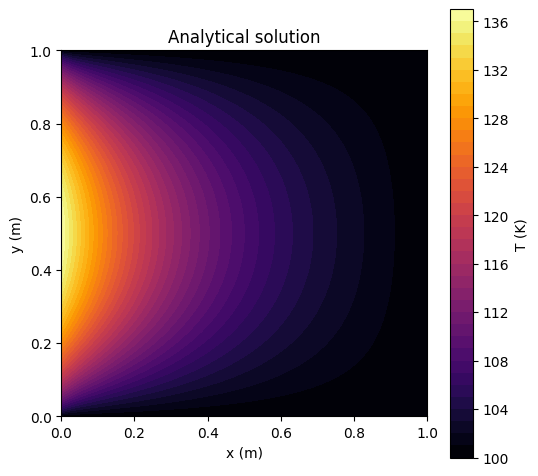

In [6]:
import matplotlib.pyplot as plt

n_grid = 101
xg = np.linspace(0, 1, n_grid); yg = np.linspace(0, 1, n_grid)
Xg, Yg = np.meshgrid(xg, yg)
Tg = np.array([[T_analytical(x, y, N=300) for x in xg] for y in yg])

print(f"min={Tg.min():.2f} K   max={Tg.max():.2f} K   mean={Tg.mean():.2f} K")
print(f"center T(0.5,0.5) = {T_analytical(0.5,0.5):.2f} K")
print(f"hot-edge midpoint T(0,0.5) = {T_analytical(0.0,0.5):.2f} K")

fig, ax = plt.subplots(figsize=(5.5,5))
c = ax.contourf(Xg, Yg, Tg, levels=40, cmap='inferno')
plt.colorbar(c, label='T (K)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_title('Analytical solution')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 2. PINN

### 2.1 Nondimensionalization

Neumann condition itself supplies the natural scale as it's the only place a physical magnitude enters the problem:
$$\Delta T = \frac{q_0 L}{k} = 100\text{ K, } \qquad T_{\text{ref}}=T_{\text{other}}=100\text{ K}, \qquad \theta=\frac{T-T_{\text{ref}}}{\Delta T}$$

Substituting into the PDE :
$$\theta_{xx}+\theta_{yy}=0$$

And the Neumann condition becomes dimensionless:
$$\frac{\partial T}{\partial x}=-Q \;\Longrightarrow\; \Delta T\cdot\theta_x = -Q \;\Longrightarrow\; \theta_x(0,y) = -\frac{QL}{\Delta T} = -1$$

(since $Q=q_0/k$ and $\Delta T=q_0L/k$, the ratio is exactly $1/L=1$). For three Dirichlet sides: $\theta=0$.

### 2.2 Network

Similar to the prev case.
$$f = \hat\theta_{xx}+\hat\theta_{yy} = -2\sum_j w^2_j\,\phi_j\,c_j$$
(same $\phi_j=h_j(1-h_j^2)$, $c_j=(W^1_{j,1})^2+(W^1_{j,2})^2$ as before. Every residual gradient formula from the prev case is the same)

### 2.3 Neumann boundary loss

The left edge supplies a **derivative** target. Define
$$p(x,y) := \frac{\partial\hat\theta}{\partial x} = \sum_j w^2_j\,\psi_j\,W^1_{j,1}, \qquad \psi_j := 1-h_j^2$$

and the Neumann loss $\text{MSE}_N=\frac1{N_n}\sum_i (p_i-(-1))^2$. This needs the parameter-gradient of $p$ itself
$$\frac{\partial p}{\partial w^2_j}=\psi_j W^1_{j,1}, \qquad \frac{\partial p}{\partial b^2}=0$$

For $W^1_{j,1}$, product rule between the **explicit** factor $W^1_{j,1}$ and the **implicit** dependence of $\psi_j$ on it (chain: $d\psi_j/dh_j=-2h_j$, $dh_j/ds_j=1-h_j^2=\psi_j$, $ds_j/dW^1_{j,1}=x$):
$$\frac{\partial p}{\partial W^1_{j,1}} = w^2_j\Big[\psi_j + (-2h_j\psi_j\,x)\,W^1_{j,1}\Big]$$

For $W^1_{j,2}$, there's no explicit factor (only $x$ appears explicitly in $p$) , but only the implicit chain through $\psi_j$, with $y$ in place of $x$:
$$\frac{\partial p}{\partial W^1_{j,2}} = w^2_j\,(-2h_j\psi_j\,y)\,W^1_{j,1}$$

And $b^1_j$, same implicit chain with $ds_j/db^1_j=1$:
$$\frac{\partial p}{\partial b^1_j} = w^2_j\,(-2h_j\psi_j)\,W^1_{j,1}$$

Total loss: $\mathcal L = \text{MSE}_D\,(\text{3 Dirichlet edges}) + \text{MSE}_N\,(\text{Neumann edge}) + \text{MSE}_f\,(\text{interior})$.

In [7]:
m = 24
rng = np.random.default_rng(0)
W1 = rng.standard_normal((m, 2)) * 0.7
b1 = np.zeros(m)
w2 = rng.standard_normal(m) * 0.5
b2 = 0.0

dT = Q * L               # = 100 K
T_ref = T_other
theta_dirichlet_target = 0.0
theta_neumann_target = -1.0

def forward(X):
    H = np.tanh(X @ W1.T + b1)
    return H @ w2 + b2, H

def theta_x(X):
    H = np.tanh(X @ W1.T + b1)
    psi = 1 - H**2
    p = (psi * W1[:,0]) @ w2
    return p, H, psi

def residual(X):
    H = np.tanh(X @ W1.T + b1)
    c = W1[:,0]**2 + W1[:,1]**2
    phi = H * (1 - H**2)
    f = -2*(phi*c) @ w2
    return f, H, phi, c

In [8]:
n_side = 25
xs = np.linspace(0, 1, n_side)

Xd = np.vstack([
    np.stack([np.ones(n_side),  xs], 1),   # right, Dirichlet
    np.stack([xs, np.zeros(n_side)], 1),   # bottom, Dirichlet
    np.stack([xs, np.ones(n_side)], 1),    # top, Dirichlet
])
theta_d = np.full(Xd.shape[0], theta_dirichlet_target)

Xn = np.stack([np.zeros(n_side), xs], 1)   # left, Neumann
theta_n = np.full(n_side, theta_neumann_target)

n_f = 30
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, n_f), np.linspace(0.02, 0.98, n_f))
Xf = np.stack([gx.ravel(), gy.ravel()], 1)

In [9]:
def grads():
    Nd, Nn, Nf = Xd.shape[0], Xn.shape[0], Xf.shape[0]

    # Dirichlet (3 edges)
    th_d, H_d = forward(Xd); e_d = th_d - theta_d
    dphi_d = 1 - H_d**2
    common_d = e_d[:,None]*w2[None,:]*dphi_d
    gW1_d = (2/Nd)*(common_d.T @ Xd); gb1_d = (2/Nd)*common_d.sum(0)
    gW2_d = (2/Nd)*(H_d.T @ e_d);     gb2_d = (2/Nd)*e_d.sum()

    # Neumann
    p_n, H_n, psi_n = theta_x(Xn)
    e_n = p_n - theta_n
    x_n, y_n = Xn[:,0:1], Xn[:,1:2]
    dpsi_dW11 = -2*H_n*psi_n*x_n
    dpsi_dW12 = -2*H_n*psi_n*y_n
    dpsi_db1  = -2*H_n*psi_n
    dp_dW11 = w2[None,:]*(psi_n + dpsi_dW11*W1[:,0][None,:])
    dp_dW12 = w2[None,:]*(dpsi_dW12*W1[:,0][None,:])
    dp_db1  = w2[None,:]*(dpsi_db1*W1[:,0][None,:])
    dp_dw2  = psi_n*W1[:,0][None,:]
    gW1_n = np.stack([(2/Nn)*(e_n[:,None]*dp_dW11).sum(0),
                       (2/Nn)*(e_n[:,None]*dp_dW12).sum(0)], axis=1)
    gb1_n = (2/Nn)*(e_n[:,None]*dp_db1).sum(0)
    gW2_n = (2/Nn)*(e_n[:,None]*dp_dw2).sum(0)

    # PDE residual
    f, H_f, phi_f, c = residual(Xf)
    onemh2 = 1-H_f**2; dphidh = 1-3*H_f**2
    xf, yf = Xf[:,0:1], Xf[:,1:2]
    dfdW11 = -2*w2[None,:]*(dphidh*onemh2*xf*c[None,:] + phi_f*2*W1[:,0][None,:])
    dfdW12 = -2*w2[None,:]*(dphidh*onemh2*yf*c[None,:] + phi_f*2*W1[:,1][None,:])
    dfdb1  = -2*w2[None,:]*(dphidh*onemh2*c[None,:])
    gW1_f = np.stack([(2/Nf)*(f[:,None]*dfdW11).sum(0), (2/Nf)*(f[:,None]*dfdW12).sum(0)], axis=1)
    gb1_f = (2/Nf)*(f[:,None]*dfdb1).sum(0)
    gW2_f = (2/Nf)*(f[:,None]*(-2*phi_f*c[None,:])).sum(0)

    gW1 = gW1_d+gW1_n+gW1_f
    gb1 = gb1_d+gb1_n+gb1_f
    gW2 = gW2_d+gW2_n+gW2_f
    gb2 = gb2_d                       # b2 doesn't appear in p or f
    return gW1, gb1, gW2, gb2, np.mean(e_d**2), np.mean(e_n**2), np.mean(f**2)

### 2.4 Losses and Approximation to the analytical solution





In [10]:
lr = 0.02
n_iters = 150_000
history = []

for it in range(n_iters + 1):
    gW1, gb1, gW2, gb2_, l_d, l_n, l_f = grads()
    W1 -= lr*gW1; b1 -= lr*gb1; w2 -= lr*gW2; b2 -= lr*gb2_
    if it % 15_000 == 0:
        history.append((it, l_d, l_n, l_f))
        print(f"{it:7d}  dirichlet={l_d:.6f}  neumann={l_n:.6f}  pde={l_f:.6f}  total={l_d+l_n+l_f:.6f}")

      0  dirichlet=0.048269  neumann=0.546765  pde=0.610983  total=1.206016
  15000  dirichlet=0.006161  neumann=0.001109  pde=0.001259  total=0.008529
  30000  dirichlet=0.005828  neumann=0.000969  pde=0.001005  total=0.007801
  45000  dirichlet=0.005598  neumann=0.000903  pde=0.000892  total=0.007393
  60000  dirichlet=0.005379  neumann=0.000861  pde=0.000811  total=0.007051
  75000  dirichlet=0.005151  neumann=0.000832  pde=0.000747  total=0.006729
  90000  dirichlet=0.004894  neumann=0.000828  pde=0.000673  total=0.006395
 105000  dirichlet=0.004574  neumann=0.000874  pde=0.000563  total=0.006011
 120000  dirichlet=0.004302  neumann=0.000816  pde=0.000503  total=0.005621
 135000  dirichlet=0.004101  neumann=0.000705  pde=0.000457  total=0.005262
 150000  dirichlet=0.003917  neumann=0.001392  pde=0.001249  total=0.006558


In [11]:
theta_grid, _ = forward(np.stack([Xg.ravel(), Yg.ravel()], 1))
T_pinn = (T_ref + dT*theta_grid).reshape(Xg.shape)
err = T_pinn - Tg

print(f"max |error| = {np.max(np.abs(err)):.1f} K")
print(f"mean |error| = {np.mean(np.abs(err)):.1f} K")
print(f"relative L2 error = {np.linalg.norm(err)/np.linalg.norm(Tg):.4f}")
print(f"center: PINN={T_ref+dT*forward(np.array([[0.5,0.5]]))[0][0]:.1f} K   exact={T_analytical(0.5,0.5):.1f} K")
print(f"hot-edge midpoint: PINN={T_ref+dT*forward(np.array([[0.0,0.5]]))[0][0]:.1f} K   exact={T_analytical(0.0,0.5):.1f} K")

max |error| = 18.1 K
mean |error| = 2.9 K
relative L2 error = 0.0345
center: PINN=105.9 K   exact=108.0 K
hot-edge midpoint: PINN=138.7 K   exact=137.0 K


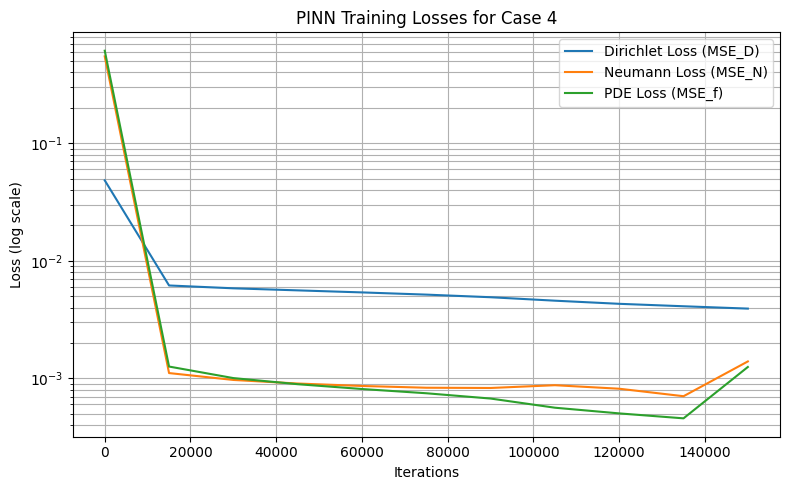

In [12]:
history_arr = np.array(history)
iterations = history_arr[:, 0]
dirichlet_loss = history_arr[:, 1]
neumann_loss = history_arr[:, 2]
pde_loss = history_arr[:, 3]

plt.figure(figsize=(8, 5))
plt.plot(iterations, dirichlet_loss, label='Dirichlet Loss (MSE_D)')
plt.plot(iterations, neumann_loss, label='Neumann Loss (MSE_N)')
plt.plot(iterations, pde_loss, label='PDE Loss (MSE_f)')
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Loss (log scale)')
plt.title('PINN Training Losses for Case 4')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

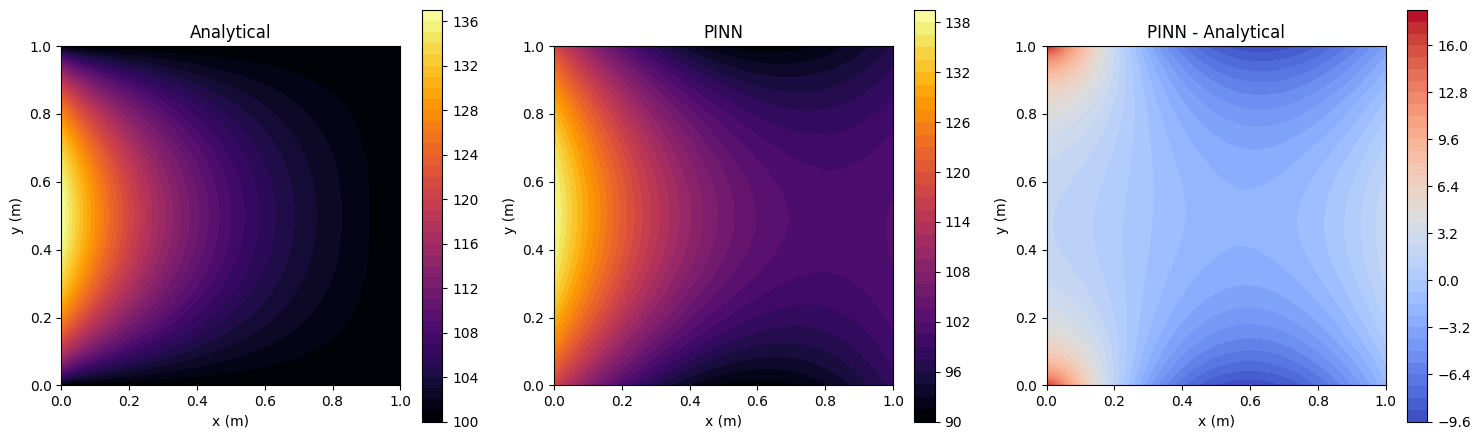

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, field, title, cmap in zip(
        axes, [Tg, T_pinn, err],
        ['Analytical', 'PINN', 'PINN - Analytical'],
        ['inferno', 'inferno', 'coolwarm']):
    c = ax.contourf(Xg, Yg, field, levels=40, cmap=cmap)
    plt.colorbar(c, ax=ax)
    ax.set_title(title); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 3.Notes
Relative $L_2$ error is less copmared to what the pure-generation problem gave with the same network size, iteration budget, and learning rate. The reason is, in the first problem there was a  **Dirichlet–Dirichlet discontinuity**(jump discontinuity)at two corners (700 K to 350 K), which inflates error near those points. Here, the corners are **Neumann–Dirichlet**: temperature stays continuous across them (only its *derivative* has a jump), which is a much gentler feature for a $\tanh$ network to approximate.

The PINN loss now has *three* pieces instead of two: Dirichlet data, Neumann data (a derivative target instead of a value target), and the PDE residual.


# Case 4: 2D Steady-State Heat Conduction without generation(Neumann +  Robin BC)

**Problem.** Square plate, $1\text{ m}\times1\text{ m}$, $k=10\ \text{W/m·K}$, no volumetric generation.

Governing equation (pure Laplace):
$$\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}=0$$

Boundary conditions:
- Left ($x=0$): uniform applied flux $q_0=500\ \text{W/m}^2$ (Neumann)
- Right, top, bottom: convection to ambient air, $h=15\ \text{W/m}^2\text{K}$, $T_\infty=300$ K (Robin)


In [15]:
k = 10.0
q0 = 500.0     # W/m^2, applied into the domain at x=0
h = 15.0       # W/m^2.K, convective coefficient
T_inf = 300.0  # K, ambient
L = 1.0

## 1. Analytical solution

### 1.1 Sign conventions

For the Neumann side:
$$\frac{\partial T}{\partial x}\bigg|_{x=0} = -Q,\qquad Q=\frac{q_0}{k}=50\text{ K/m}$$

For convective(Robin) conditions:
$$x=1:\ \ \frac{\partial T}{\partial x} = -\mathrm{Bi}\,(T-T_\infty), \qquad y=0:\ \ \frac{\partial T}{\partial y} = \mathrm{Bi}\,(T-T_\infty), \qquad y=1:\ \ \frac{\partial T}{\partial y} = -\mathrm{Bi}\,(T-T_\infty)$$

where $\mathrm{Bi}=hL/k=1.5$ is the Biot number — the natural dimensionless group for a convective boundary.

In [16]:
Q = q0/k    # 50 K/m
Bi = h*L/k  # 1.5

### 1.2 Shift by $T_\infty$

$\theta=T-T_\infty$ makes all three Robin conditions homogeneous (no $T_\infty$ term left) while leaving $\nabla^2\theta=0$ and the Neumann condition unchanged:
$$\theta_x(0,y)=-Q,\quad \theta_x(1,y)=-\mathrm{Bi}\,\theta(1,y),\quad \theta_y(x,0)=\mathrm{Bi}\,\theta(x,0),\quad \theta_y(x,1)=-\mathrm{Bi}\,\theta(x,1)$$

### 1.3 Eigenvalue problem in $y$

The $y=0$ and $y=1$ conditions are symmetric under $y\to1-y$, and the forcing (the $x=0$ flux) so only the **symmetric** eigenfunctions get excited. Try $Y(y)=\cos\big(\mu(y-\tfrac12)\big)$ (automatically symmetric) and enforce the $y=0$ Robin condition:
$$Y'(0)=\mu\sin(\mu/2), \qquad Y(0)=\cos(\mu/2) \quad\Longrightarrow\quad \mu\sin(\mu/2)=\mathrm{Bi}\cos(\mu/2)$$

$$\boxed{\mu\tan(\mu/2)=\mathrm{Bi}}$$



In [18]:
import numpy as np
from scipy.optimize import brentq

def eig_eq(mu):
    return mu*np.tan(mu/2) - Bi

N_modes = 40
mus = []
lo = 1e-6
for kk in range(N_modes):
    hi = (2*kk+1)*np.pi - 1e-6          # tan(mu/2) has a pole here
    xs = np.linspace(lo, hi, 3000)
    vals = eig_eq(xs)
    for i in range(len(xs)-1):
        if np.isfinite(vals[i]) and np.isfinite(vals[i+1]) and np.sign(vals[i]) != np.sign(vals[i+1]):
            r = brentq(eig_eq, xs[i], xs[i+1])
            if not mus or r - mus[-1] > 1e-4:
                mus.append(r)
    lo = hi + 2e-6
mus = np.array(mus)

print("first 6 eigenvalues:", np.round(mus[:6], 5))

first 6 eigenvalues: [ 1.54272  6.72227 12.79969 19.00707 25.25141 31.51106]


### 1.4 $x$-direction and matching the flux

For each mode, $X_n''-\mu_n^2X_n=0$, so $X_n(x)=\cosh(\mu_nx)+C_n\sinh(\mu_nx)$. Pick $C_n$ so the $x=1$ Robin condition is satisfied automatically (same trick as before — build the boundary condition into the basis function rather than fitting it afterward):
$$C_n = -\frac{\mathrm{Bi}\cosh(\mu_n)+\mu_n\sinh(\mu_n)}{\mu_n\cosh(\mu_n)+\mathrm{Bi}\sinh(\mu_n)}$$

Write $\varphi_n(x)=\cosh(\mu_nx)+C_n\sinh(\mu_nx)$. The full solution is $\theta(x,y)=\sum_n D_n\varphi_n(x)\cos\big(\mu_n(y-\tfrac12)\big)$, and $D_n$ is fixed by matching the $x=0$ flux: $\varphi_n'(0)=C_n\mu_n$, so
$$\sum_n D_nC_n\mu_n\cos\big(\mu_n(y-\tfrac12)\big) = -Q$$

The $\cos(\mu_n(y-\tfrac12))$ are eigenfunctions of a self-adjoint Sturm-Liouville problem, hence orthogonal — project the constant $-Q$ onto this basis the same way a Fourier sine series was used in the earlier problems, just with these eigenfunctions and eigenvalues instead:
$$D_n = \frac{\gamma_n}{C_n\mu_n}, \qquad \gamma_n = \frac{-Q\int_0^1\cos(\mu_n(y-\tfrac12))\,dy}{\int_0^1\cos^2(\mu_n(y-\tfrac12))\,dy} = \frac{-4Q\sin(\mu_n/2)}{\mu_n+\sin(\mu_n)}$$

$$\boxed{T(x,y) = T_\infty + \sum_{n=1}^{\infty} D_n\,\varphi_n(x)\,\cos\big(\mu_n(y-\tfrac12)\big)}$$

In [19]:
def Cn(mu):
    return -(Bi*np.cosh(mu) + mu*np.sinh(mu)) / (mu*np.cosh(mu) + Bi*np.sinh(mu))

def phi(mu, x, c):
    return np.cosh(mu*x) + c*np.sinh(mu*x)

def gamma(mu):
    return -4*Q*np.sin(mu/2) / (mu + np.sin(mu))

Cs = Cn(mus)
Ds = gamma(mus) / (Cs*mus)

def T_analytical(x, y):
    T = T_inf
    for mu, c, D in zip(mus, Cs, Ds):
        T += D * phi(mu, x, c) * np.cos(mu*(y-0.5))
    return T

In [20]:
eps = 1e-5
print("Neumann at x=0 (target -50):")
for y in [0.1, 0.3, 0.5, 0.7, 0.9]:
    print(f"  y={y}: dT/dx = {(T_analytical(eps,y)-T_analytical(0.0,y))/eps:.2f}")

print("Robin at x=1 (target -Bi*(T-Tinf)):")
for y in [0.1, 0.3, 0.5, 0.7, 0.9]:
    dTdx = (T_analytical(1.0,y)-T_analytical(1.0-eps,y))/eps
    Tv = T_analytical(1.0,y)
    print(f"  y={y}: dT/dx={dTdx:.3f}  target={-Bi*(Tv-T_inf):.3f}  T={Tv:.2f}")

print("Robin at y=0 (target +Bi*(T-Tinf)):")
for x in [0.1, 0.3, 0.5, 0.7, 0.9]:
    dTdy = (T_analytical(x,eps)-T_analytical(x,0.0))/eps
    Tv = T_analytical(x,0.0)
    print(f"  x={x}: dT/dy={dTdy:.3f}  target={Bi*(Tv-T_inf):.3f}  T={Tv:.2f}")

Neumann at x=0 (target -50):
  y=0.1: dT/dx = -50.00
  y=0.3: dT/dx = -50.00
  y=0.5: dT/dx = -50.00
  y=0.7: dT/dx = -50.00
  y=0.9: dT/dx = -50.00
Robin at x=1 (target -Bi*(T-Tinf)):
  y=0.1: dT/dx=-9.437  target=-9.437  T=306.29
  y=0.3: dT/dx=-11.021  target=-11.021  T=307.35
  y=0.5: dT/dx=-11.565  target=-11.565  T=307.71
  y=0.7: dT/dx=-11.021  target=-11.021  T=307.35
  y=0.9: dT/dx=-9.437  target=-9.437  T=306.29
Robin at y=0 (target +Bi*(T-Tinf)):
  x=0.1: dT/dy=33.562  target=33.562  T=322.37
  x=0.3: dT/dy=24.302  target=24.302  T=316.20
  x=0.5: dT/dy=17.788  target=17.788  T=311.86
  x=0.7: dT/dy=13.077  target=13.077  T=308.72
  x=0.9: dT/dy=9.645  target=9.645  T=306.43


min=305.53 K   max=334.80 K   mean=316.44 K
center T(0.5,0.5) = 316.47 K
flux-edge midpoint T(0,0.5) = 334.80 K


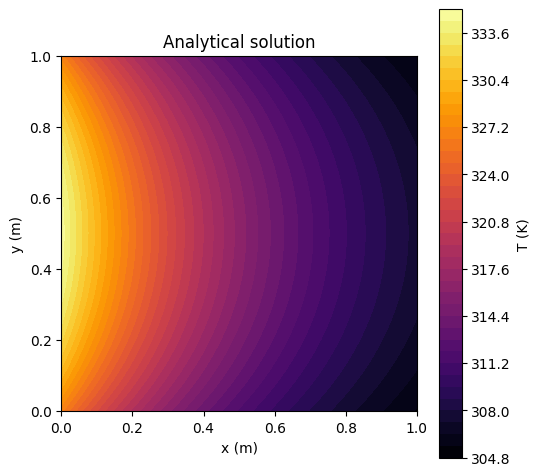

In [21]:
import matplotlib.pyplot as plt

n_grid = 101
xg = np.linspace(0, 1, n_grid); yg = np.linspace(0, 1, n_grid)
Xg, Yg = np.meshgrid(xg, yg)
Tg = np.array([[T_analytical(x, y) for x in xg] for y in yg])

print(f"min={Tg.min():.2f} K   max={Tg.max():.2f} K   mean={Tg.mean():.2f} K")
print(f"center T(0.5,0.5) = {T_analytical(0.5,0.5):.2f} K")
print(f"flux-edge midpoint T(0,0.5) = {T_analytical(0.0,0.5):.2f} K")

fig, ax = plt.subplots(figsize=(5.5,5))
c = ax.contourf(Xg, Yg, Tg, levels=40, cmap='inferno')
plt.colorbar(c, label='T (K)')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_title('Analytical solution')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 2. PINN

### 2.1 Nondimensionalization

The boundary flux gives the scale term. Use the same $\Delta T$ as before, and shift by $T_\infty$:
$$\Delta T = \frac{q_0L}{k}=50\text{ K},\qquad T_{\text{ref}}=T_\infty=300\text{ K},\qquad \theta=\frac{T-300}{50}$$

Substituting into every boundary condition, the Biot number survives **unchanged** into the dimensionless form — it's already dimensionless by construction (that's the whole point of a Biot number):
$$\theta_{xx}+\theta_{yy}=0$$
$$\theta_x(0,y)=-1, \qquad \theta_x(1,y)=-\mathrm{Bi}\,\theta(1,y), \qquad \theta_y(x,0)=\mathrm{Bi}\,\theta(x,0), \qquad \theta_y(x,1)=-\mathrm{Bi}\,\theta(x,1)$$

### 2.2 Architecture

Same single hidden layer. What's different is that the network's forward pass now needs to supply **three distinct quantities** at various boundary points: the raw output $\hat\theta$ (for the Robin sides' value term), its $x$-derivative $\hat\theta_x$ (for the Neumann side, and the $x=1$ Robin term), and its $y$-derivative $\hat\theta_y$ (new — needed for the $y=0,1$ Robin terms)

### 2.3 Deriving $\hat\theta_y$ — the mirror piece

$\hat\theta_x$ was already derived for the Neumann problem. $\hat\theta_y$ is the direct mirror, swapping the roles of $x\leftrightarrow y$ and $W^1_{j,1}\leftrightarrow W^1_{j,2}$:
$$p_y := \hat\theta_y = \sum_j w^2_j\,\psi_j\,W^1_{j,2}, \qquad \psi_j=1-h_j^2$$
$$\frac{\partial p_y}{\partial W^1_{j,2}} = w^2_j\Big[\psi_j - 2h_j\psi_j\,y\,W^1_{j,2}\Big] \quad\text{(explicit + implicit, mirrors the }W^1_{j,1}\text{ case for }p_x\text{)}$$
$$\frac{\partial p_y}{\partial W^1_{j,1}} = -2w^2_jh_j\psi_j\,x\,W^1_{j,2} \quad\text{(implicit only, mirrors the other case)}$$
$$\frac{\partial p_y}{\partial b^1_j} = -2w^2_jh_j\psi_j\,W^1_{j,2}, \qquad \frac{\partial p_y}{\partial w^2_j}=\psi_jW^1_{j,2}, \qquad \frac{\partial p_y}{\partial b^2}=0$$

### 2.4 The Robin residuals — combining pieces you already have

A Robin residual is a **linear combination** of a derivative term and a value term, e.g. at $x=1$: $r=\hat\theta_x+\mathrm{Bi}\,\hat\theta$. Since gradients are linear, its parameter gradient is just the same combination of the two pieces' gradients you already derived — $\hat\theta$'s gradient is ordinary backprop (used for the Dirichlet loss in the very first problem), $\hat\theta_x$'s gradient was derived for the Neumann problem, and $\hat\theta_y$'s gradient is the mirror just above. No new derivation is actually needed for the Robin terms themselves — only the bookkeeping of adding two known gradients with the right sign and the right Biot-number weight, per edge:

$$r_{x=1}=\hat\theta_x+\mathrm{Bi}\,\hat\theta \qquad r_{y=0}=\hat\theta_y-\mathrm{Bi}\,\hat\theta \qquad r_{y=1}=\hat\theta_y+\mathrm{Bi}\,\hat\theta$$

Total loss, five terms, **no Dirichlet term at all**:
$$\mathcal L = \underbrace{\text{MSE}(\hat\theta_x+1)}_{\text{Neumann, }x=0} + \underbrace{\text{MSE}(r_{x=1})}_{\text{Robin, right}} + \underbrace{\text{MSE}(r_{y=0})}_{\text{Robin, bottom}} + \underbrace{\text{MSE}(r_{y=1})}_{\text{Robin, top}} + \underbrace{\text{MSE}(f)}_{\text{PDE, interior}}$$

In [22]:
m = 24
rng = np.random.default_rng(0)
W1 = rng.standard_normal((m, 2)) * 0.7
b1 = np.zeros(m)
w2 = rng.standard_normal(m) * 0.5
b2 = 0.0

dT = Q * L         # 50 K
T_ref = T_inf       # 300 K

def theta_grads(X):
    '''theta_hat and its parameter-gradients at each point in X.'''
    H = np.tanh(X @ W1.T + b1)
    theta = H @ w2 + b2
    x_, y_ = X[:,0:1], X[:,1:2]
    g = {'W11': w2[None,:]*(1-H**2)*x_, 'W12': w2[None,:]*(1-H**2)*y_,
         'b1': w2[None,:]*(1-H**2), 'w2': H, 'b2': np.ones(X.shape[0])}
    return theta, g

def thetax_grads(X):
    '''theta_hat_x and its parameter-gradients.'''
    H = np.tanh(X @ W1.T + b1); psi = 1 - H**2
    p = (psi * W1[:,0]) @ w2
    x_, y_ = X[:,0:1], X[:,1:2]
    dpsi11, dpsi12, dpsi_b1 = -2*H*psi*x_, -2*H*psi*y_, -2*H*psi
    g = {'W11': w2[None,:]*(psi + dpsi11*W1[:,0][None,:]),
         'W12': w2[None,:]*(dpsi12*W1[:,0][None,:]),
         'b1':  w2[None,:]*(dpsi_b1*W1[:,0][None,:]),
         'w2':  psi*W1[:,0][None,:], 'b2': np.zeros(X.shape[0])}
    return p, g

def thetay_grads(X):
    '''theta_hat_y and its parameter-gradients (mirror of thetax_grads).'''
    H = np.tanh(X @ W1.T + b1); psi = 1 - H**2
    p = (psi * W1[:,1]) @ w2
    x_, y_ = X[:,0:1], X[:,1:2]
    dpsi11, dpsi12, dpsi_b1 = -2*H*psi*x_, -2*H*psi*y_, -2*H*psi
    g = {'W11': w2[None,:]*(dpsi11*W1[:,1][None,:]),
         'W12': w2[None,:]*(psi + dpsi12*W1[:,1][None,:]),
         'b1':  w2[None,:]*(dpsi_b1*W1[:,1][None,:]),
         'w2':  psi*W1[:,1][None,:], 'b2': np.zeros(X.shape[0])}
    return p, g

def residual_grads(X):
    '''PDE residual f = theta_hat_xx + theta_hat_yy, and its parameter-gradients.'''
    H = np.tanh(X @ W1.T + b1)
    c = W1[:,0]**2 + W1[:,1]**2; phi = H*(1-H**2)
    f = -2*(phi*c) @ w2
    onemh2, dphidh = 1-H**2, 1-3*H**2
    x_, y_ = X[:,0:1], X[:,1:2]
    g = {'W11': -2*w2[None,:]*(dphidh*onemh2*x_*c[None,:] + phi*2*W1[:,0][None,:]),
         'W12': -2*w2[None,:]*(dphidh*onemh2*y_*c[None,:] + phi*2*W1[:,1][None,:]),
         'b1':  -2*w2[None,:]*(dphidh*onemh2*c[None,:]),
         'w2':  -2*phi*c[None,:], 'b2': np.zeros(X.shape[0])}
    return f, g

def combine(g1, c1, g2, c2):
    return {kk: c1*g1[kk] + c2*g2[kk] for kk in g1}

def accumulate(res, g, N):
    gW1 = np.stack([(2/N)*(res[:,None]*g['W11']).sum(0), (2/N)*(res[:,None]*g['W12']).sum(0)], axis=1)
    gb1 = (2/N)*(res[:,None]*g['b1']).sum(0)
    gw2 = (2/N)*(res[:,None]*g['w2']).sum(0)
    gb2 = (2/N)*(res*g['b2']).sum()
    return gW1, gb1, gw2, gb2

In [23]:
n_side = 25
xs = np.linspace(0, 1, n_side)
X_left   = np.stack([np.zeros(n_side), xs], 1)   # Neumann, dT/dx = -1
X_right  = np.stack([np.ones(n_side),  xs], 1)   # Robin
X_bottom = np.stack([xs, np.zeros(n_side)], 1)   # Robin
X_top    = np.stack([xs, np.ones(n_side)], 1)    # Robin

n_f = 30
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, n_f), np.linspace(0.02, 0.98, n_f))
X_f = np.stack([gx.ravel(), gy.ravel()], 1)

In [24]:
def grads():
    parts, losses = [], {}

    p, g = thetax_grads(X_left)
    e = p + 1.0
    parts.append(accumulate(e, g, X_left.shape[0])); losses['neumann'] = np.mean(e**2)

    px, gpx = thetax_grads(X_right); th, gth = theta_grads(X_right)
    e = px + Bi*th; gc = combine(gpx, 1.0, gth, Bi)
    parts.append(accumulate(e, gc, X_right.shape[0])); losses['robin_right'] = np.mean(e**2)

    py, gpy = thetay_grads(X_bottom); th, gth = theta_grads(X_bottom)
    e = py - Bi*th; gc = combine(gpy, 1.0, gth, -Bi)
    parts.append(accumulate(e, gc, X_bottom.shape[0])); losses['robin_bottom'] = np.mean(e**2)

    py, gpy = thetay_grads(X_top); th, gth = theta_grads(X_top)
    e = py + Bi*th; gc = combine(gpy, 1.0, gth, Bi)
    parts.append(accumulate(e, gc, X_top.shape[0])); losses['robin_top'] = np.mean(e**2)

    f, gf = residual_grads(X_f)
    parts.append(accumulate(f, gf, X_f.shape[0])); losses['pde'] = np.mean(f**2)

    gW1 = sum(p[0] for p in parts); gb1 = sum(p[1] for p in parts)
    gw2 = sum(p[2] for p in parts); gb2 = sum(p[3] for p in parts)
    return gW1, gb1, gw2, gb2, losses

### 2.6 Train

The Robin terms couple $\hat\theta$ and its derivative through the $\mathrm{Bi}$ factor, which changes the gradient scale in a way similar to what the 1D project already flagged for Robin conditions. The learning rate that worked fine for the pure Dirichlet/Neumann problems (0.02) diverges outright here; **0.002** is stable and converges smoothly.

In [ ]:
lr = 0.002
n_iters = 150_000
for it in range(n_iters + 1):
    gW1, gb1, gw2, gb2_, losses = grads()
    W1 -= lr*gW1; b1 -= lr*gb1; w2 -= lr*gw2; b2 -= lr*gb2_
    if it % 15_000 == 0:
        total = sum(losses.values())
        print(f"{it:7d}  " + "  ".join(f"{k}={v:.6f}" for k,v in losses.items()) + f"  total={total:.6f}")

      0  neumann=0.546765  robin_right=0.865402  robin_bottom=0.533405  robin_top=0.069793  pde=0.610983  total=2.626347


  15000  neumann=0.003609  robin_right=0.000132  robin_bottom=0.002136  robin_top=0.002178  pde=0.008098  total=0.016153


  30000  neumann=0.004270  robin_right=0.000009  robin_bottom=0.000615  robin_top=0.001229  pde=0.003113  total=0.009237


  45000  neumann=0.004634  robin_right=0.000041  robin_bottom=0.000354  robin_top=0.000939  pde=0.001655  total=0.007623


  60000  neumann=0.004537  robin_right=0.000040  robin_bottom=0.000348  robin_top=0.000901  pde=0.001159  total=0.006986


...

  90000  neumann=0.004212  robin_right=0.000030  robin_bottom=0.000408  robin_top=0.000918  pde=0.000763  total=0.006331


 105000  neumann=0.004075  robin_right=0.000028  robin_bottom=0.000436  robin_top=0.000931  pde=0.000678  total=0.006148


 120000  neumann=0.003964  robin_right=0.000028  robin_bottom=0.000455  robin_top=0.000941  pde=0.000626  total=0.006013


 135000  neumann=0.003876  robin_right=0.000028  robin_bottom=0.000465  robin_top=0.000946  pde=0.000590  total=0.005905


 150000  neumann=0.003805  robin_right=0.000027  robin_bottom=0.000470  robin_top=0.000948  pde=0.000564  total=0.005814


In [ ]:
def forward(X):
    H = np.tanh(X @ W1.T + b1)
    return H @ w2 + b2

theta_grid = forward(np.stack([Xg.ravel(), Yg.ravel()], 1))
T_pinn = (T_ref + dT*theta_grid).reshape(Xg.shape)
err = T_pinn - Tg

print(f"max |error| = {np.max(np.abs(err)):.3f} K")
print(f"mean |error| = {np.mean(np.abs(err)):.4f} K")
print(f"relative L2 error = {np.linalg.norm(err)/np.linalg.norm(Tg):.5f}")
print(f"center: PINN={T_ref+dT*forward(np.array([[0.5,0.5]]))[0]:.2f} K   exact={T_analytical(0.5,0.5):.2f} K")
print(f"flux-edge midpoint: PINN={T_ref+dT*forward(np.array([[0.0,0.5]]))[0]:.2f} K   exact={T_analytical(0.0,0.5):.2f} K")

max |error| = 0.636 K
mean |error| = 0.0839 K
relative L2 error = 0.00041
center: PINN=316.46 K   exact=316.47 K
flux-edge midpoint: PINN=335.42 K   exact=334.80 K


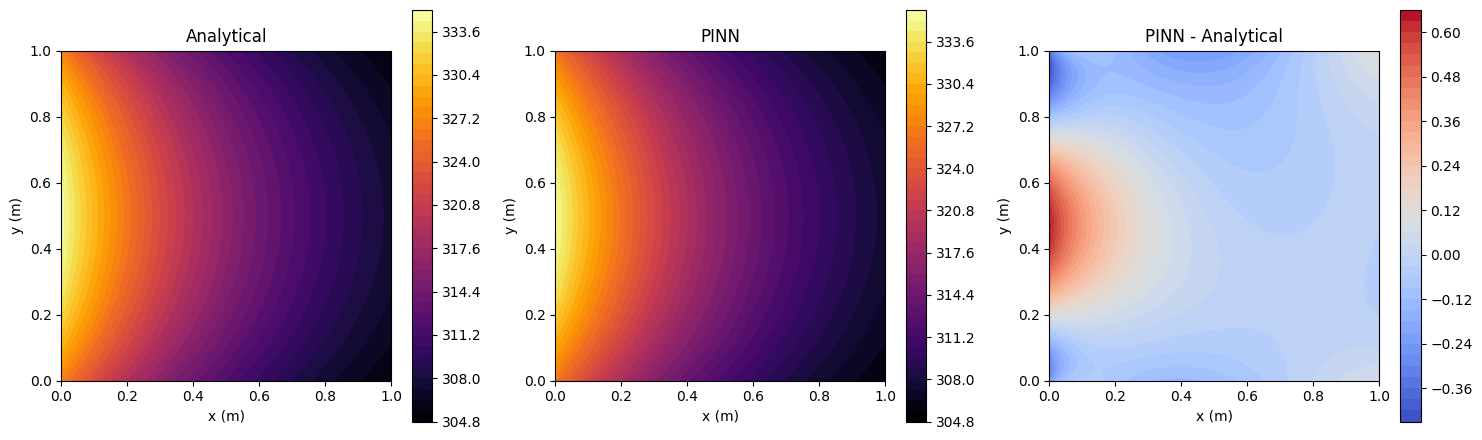

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, field, title, cmap in zip(
        axes, [Tg, T_pinn, err],
        ['Analytical', 'PINN', 'PINN - Analytical'],
        ['inferno', 'inferno', 'coolwarm']):
    c = ax.contourf(Xg, Yg, field, levels=40, cmap=cmap)
    plt.colorbar(c, ax=ax)
    ax.set_title(title); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 3. Notes

Relative $L_2$ error is the least compared to the other techniques

